# Cross-Sectional Stock Return Prediction

This notebook runs the pipeline from `stock_return_project.py`.
Use the quick settings below first; scale up to more models after the pipeline is stable.


In [2]:
import importlib
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import stock_return_project as srp
srp = importlib.reload(srp)
print(srp.__file__)


/Users/hlc/Desktop/UCLA Courses/ECE C147A/Project/stock_return_project.py


In [3]:
# Quick run defaults.
# For a full comparison later, change MODELS to ["RNN", "LSTM", "GRU", "TRANSFORMER"].
START_DATE = "2015-01-01"
END_DATE = "2025-01-01"
LOOKBACK = 60
HORIZON = 5
MODELS = ["RNN", "GRU", "TRANSFORMER"]


In [4]:
raw_prices = srp.download_price_history(start=START_DATE, end=END_DATE)
experiment_data = srp.prepare_experiment_data(
    raw_prices,
    horizon=HORIZON,
    lookback=LOOKBACK,
    train_size=0.7,
    val_size=0.15,
)
for split_name, split_df in experiment_data.splits.items():
    print(split_name, split_df["Date"].min(), split_df["Date"].max(), len(split_df))


$SNDK: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1735707600")
$Q: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1735707600")

2 Failed downloads:
['SNDK', 'Q']: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1735707600")


train 2015-02-02 00:00:00 2021-12-31 00:00:00 834929
val 2022-01-03 00:00:00 2023-06-29 00:00:00 185606
test 2023-06-30 00:00:00 2024-12-23 00:00:00 186877


In [ ]:
train_config = srp.TrainConfig(
    batch_size=256,
    hidden_dim=64,
    num_layers=2,
    dropout=0.1,
    num_heads=4,
    max_epochs=20,
    patience=5,
)

results = srp.run_model_suite(
    experiment_data,
    model_names=MODELS,
    train_config=train_config,
)


In [ ]:
summary = srp.build_summary_frame(results)
summary


,model,mean_ic,std_ic,ic_t_stat,mean_rank_ic,std_rank_ic,rank_ic_t_stat,mean_return,volatility,sharpe_ratio
0,TRANSFORMER,0.011544,0.145425,1.321118,0.005171,0.153394,0.561075,0.000412,0.006815,0.958940
1,GRU,0.010952,0.120041,1.518422,0.014346,0.159479,1.497173,0.000875,0.007106,1.955332
2,LSTM,0.010206,0.124271,1.366917,0.008372,0.167767,0.830538,0.000709,0.007621,1.476040
3,RNN,0.007924,0.068931,1.906275,0.008254,0.075926,1.802816,0.000014,0.000280,0.774227


# Result Visualizations

Plots for loss curves, IC/RankIC, portfolio performance, and model comparison.


Visualizing model: TRANSFORMER


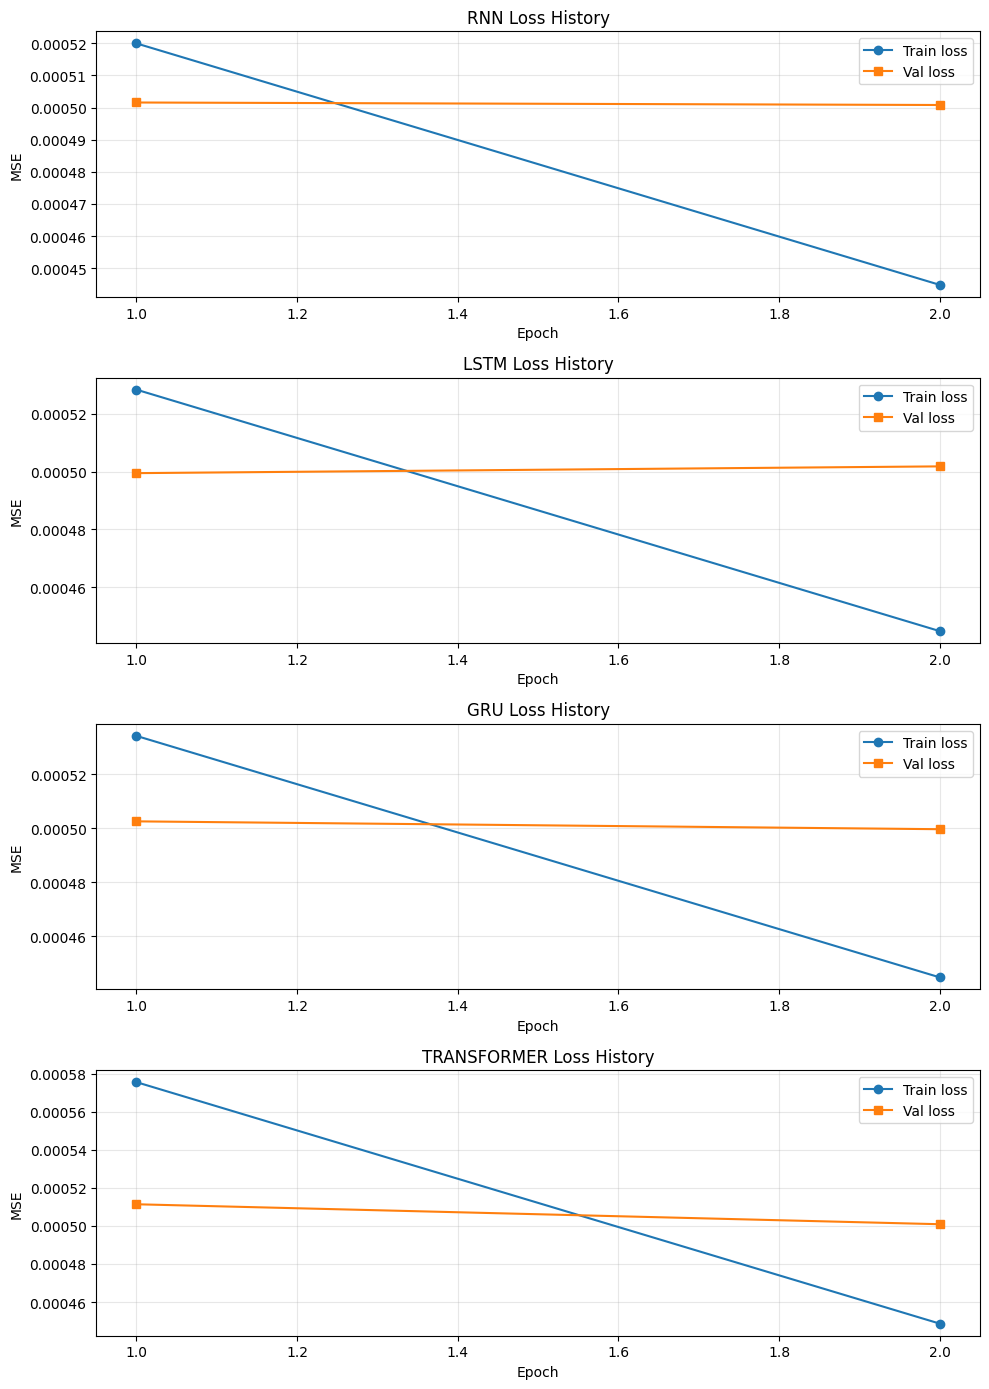

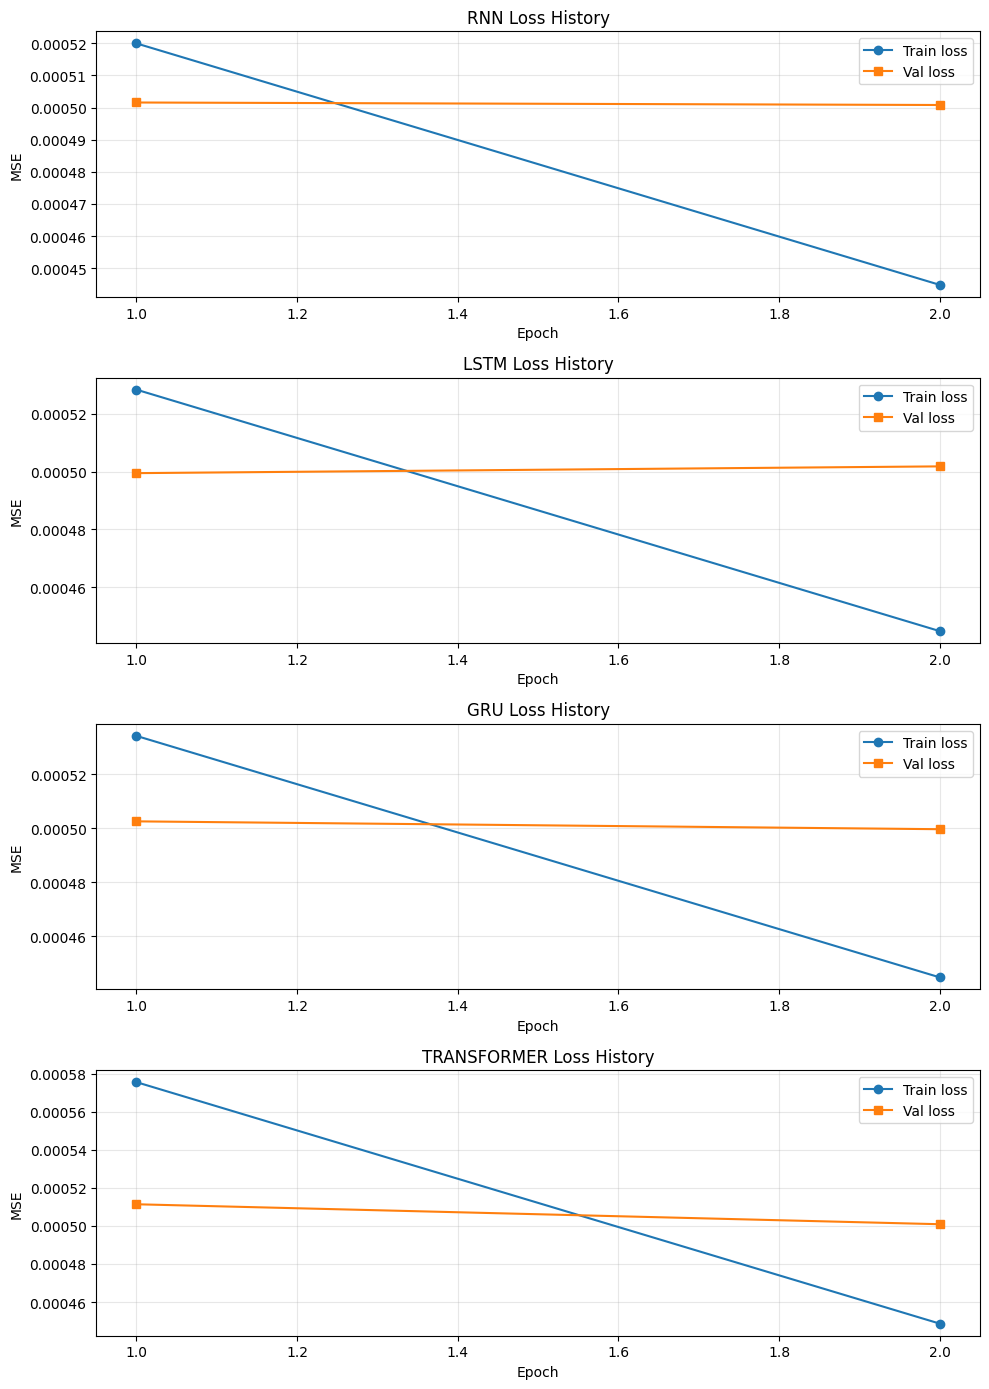

In [ ]:
best_model = summary.iloc[0]["model"]
print("Visualizing model:", best_model)
srp.plot_training_histories(results)


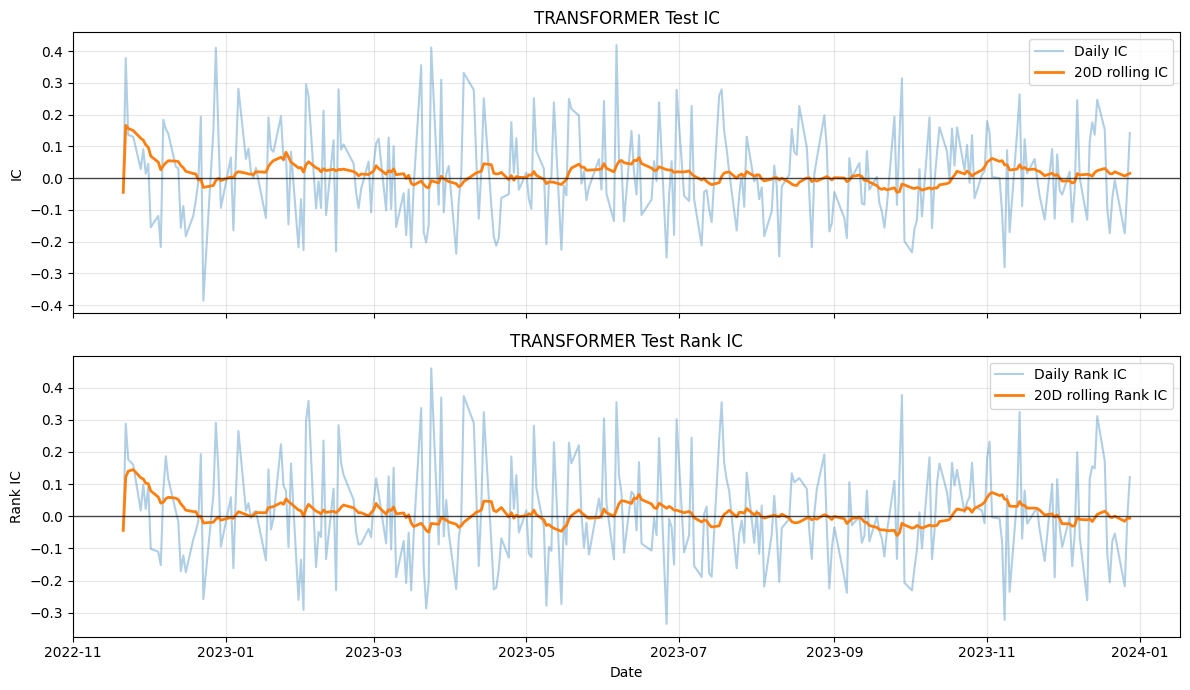

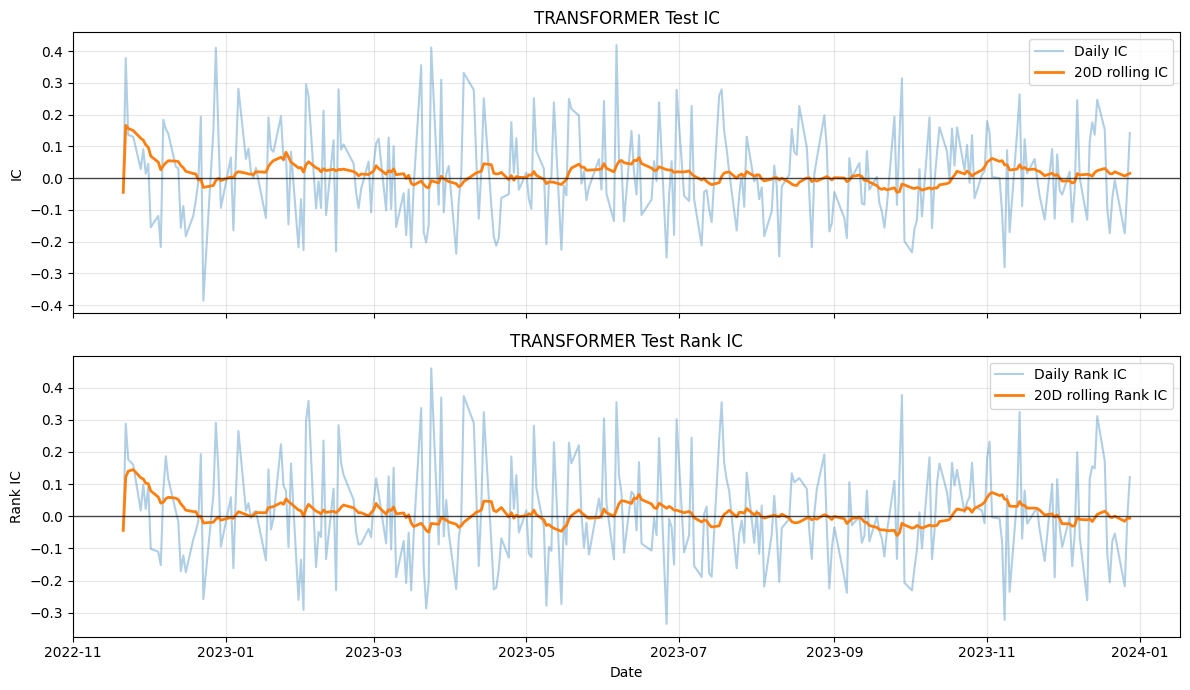

In [ ]:
srp.plot_ic_series(results, best_model, split="test", rolling_window=20)


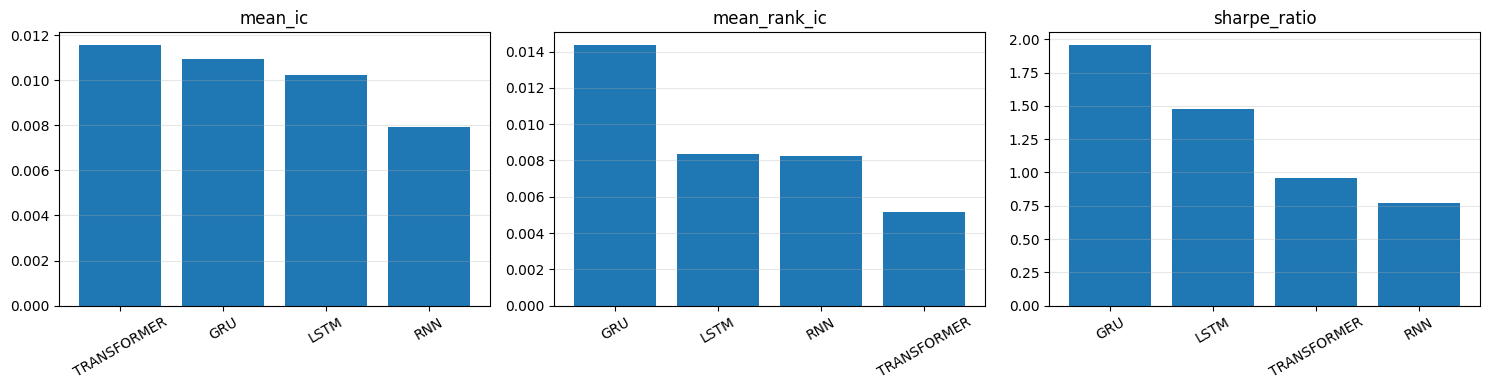

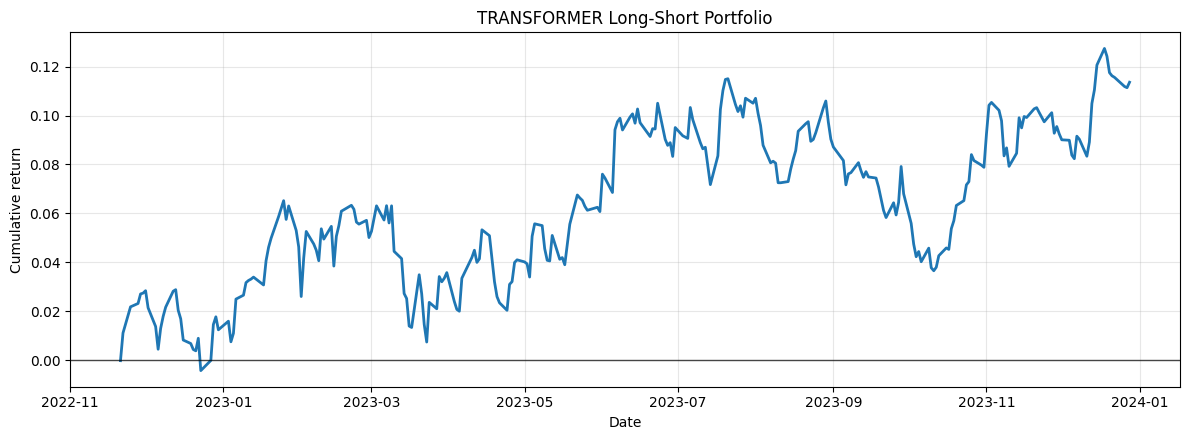

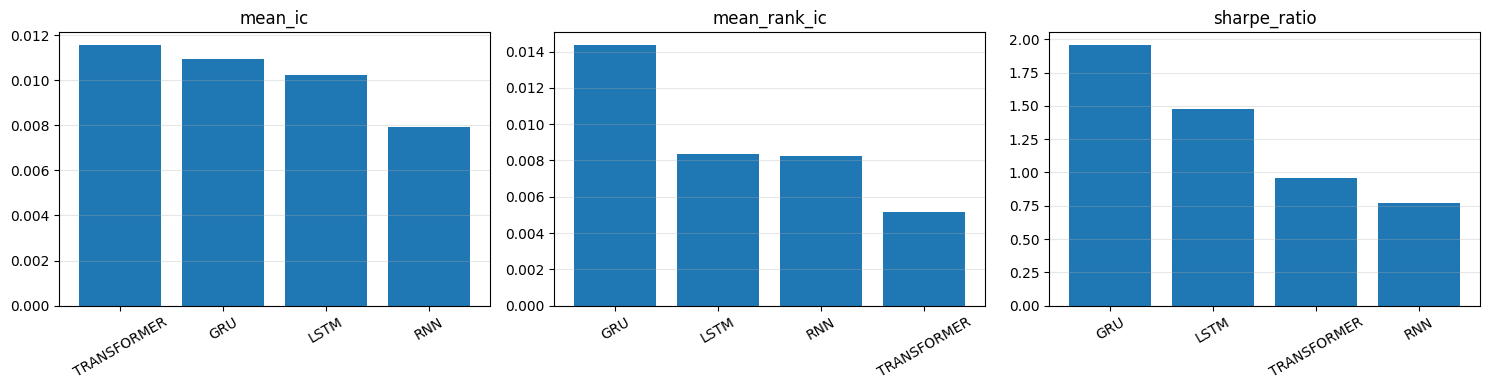

In [ ]:
srp.plot_portfolio_curve(results, best_model)
srp.plot_summary_bars(summary)


# Prediction diagnostics

Inspect raw predictions, sign accuracy, and the prediction-vs-target scatter plot.


In [ ]:
model_name = best_model
pred = results[model_name]["test_predictions"].copy()
pred.head()


,Date,Ticker,prediction,target
0,2022-11-21,A,-0.001254,0.080750
1,2022-11-21,AAPL,-0.000391,0.014661
2,2022-11-21,ABBV,-0.001140,0.017058
3,2022-11-21,ABNB,-0.000316,-0.004493
4,2022-11-21,ABT,-0.001103,0.009530


In [ ]:
pred["pred_sign"] = (pred["prediction"] > 0).astype(int)
pred["true_sign"] = (pred["target"] > 0).astype(int)

sign_accuracy = (pred["pred_sign"] == pred["true_sign"]).mean()
daily_sign_accuracy = pred.groupby("Date").apply(
    lambda x: ((x["prediction"] > 0) == (x["target"] > 0)).mean(),
    include_groups=False,
)

print("Overall sign accuracy:", round(float(sign_accuracy), 4))
daily_sign_accuracy.describe()


Overall sign accuracy: 0.481


count    277.000000
mean       0.481031
std        0.242743
min        0.042339
25%        0.280242
50%        0.473896
75%        0.653924
max        0.967742
dtype: float64

,Date,Ticker,prediction,target,pred_sign,true_sign
137509,2023-12-28,ORCL,0.000235,-0.007718,1,0
137528,2023-12-28,PLTR,-0.000106,-0.022210,0,0
137334,2023-12-28,EXC,-0.000300,0.001395,0,1
137387,2023-12-28,HPE,-0.000311,-0.011066,0,0
137369,2023-12-28,GOOG,-0.000323,-0.002477,0,0
137483,2023-12-28,MU,-0.000324,-0.006346,0,0
137491,2023-12-28,NKE,-0.000332,-0.002297,0,0
137496,2023-12-28,NTAP,-0.000342,-0.000567,0,0
137520,2023-12-28,PFE,-0.000351,0.000000,0,0
137370,2023-12-28,GOOGL,-0.000357,-0.003851,0,0


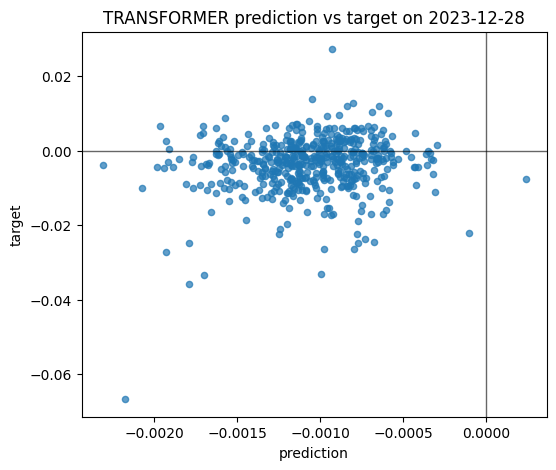

In [ ]:
import matplotlib.pyplot as plt

latest_day = pred["Date"].max()
latest_slice = pred[pred["Date"] == latest_day].copy()
display(latest_slice.sort_values("prediction", ascending=False).head(10))

ax = latest_slice.plot.scatter(
    x="prediction",
    y="target",
    figsize=(6, 5),
    alpha=0.7,
    title=f"{model_name} prediction vs target on {latest_day.date()}"
)
ax.axhline(0.0, color="black", linewidth=1, alpha=0.6)
ax.axvline(0.0, color="black", linewidth=1, alpha=0.6)
plt.show()
